In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Load LSOA sample ──────────────────────────────────────────────────────────
lsoas = pd.read_csv('data/test_lsoas.csv')
print(f'LSOAs in sample: {len(lsoas)}')

Device: cpu
LSOAs in sample: 2000


In [ ]:
# ── Load IMD sub-domain scores ────────────────────────────────────────────────
imd_full = pd.read_csv('data/govuk2.csv')
print('IMD full columns:')
print(imd_full.columns.tolist())
print(imd_full.head(2))

IMD full columns:
['LSOA code (2011)', 'LSOA name (2011)', 'Local Authority District code (2019)', 'Local Authority District name (2019)', 'Index of Multiple Deprivation (IMD) Score', 'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)', 'Income Score (rate)', 'Income Rank (where 1 is most deprived)', 'Income Decile (where 1 is most deprived 10% of LSOAs)', 'Employment Score (rate)', 'Employment Rank (where 1 is most deprived)', 'Employment Decile (where 1 is most deprived 10% of LSOAs)', 'Education, Skills and Training Score', 'Education, Skills and Training Rank (where 1 is most deprived)', 'Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)', 'Health Deprivation and Disability Score', 'Health Deprivation and Disability Rank (where 1 is most deprived)', 'Health Deprivation and Disability Decile (where 1 is most deprived 10% of LSOAs)', 'Crime Score', 'Crim

In [ ]:
# ── Extract sub-domain score columns ─────────────────────────────────────────
# The file has scores for all 7 domains — find the score columns
# Column names contain 'Score' — let's identify them
score_cols = [c for c in imd_full.columns if 'Score' in c]
lsoa_col = imd_full.columns[0]  # First column is LSOA code

print(f'LSOA code column: {lsoa_col}')
print(f'Score columns found ({len(score_cols)}):')
for c in score_cols:
    print(f'  {c}')

# Keep only LSOA code + score columns
imd_features = imd_full[[lsoa_col] + score_cols].copy()
imd_features.columns = ['LSOA11CD'] + [f'score_{i}' for i in range(len(score_cols))]

# Merge with our sample
lsoas_merged = lsoas.merge(imd_features, on='LSOA11CD', how='inner')
print(f'\nLSOAs after merge: {len(lsoas_merged)}')
print(lsoas_merged.head(2))

LSOA code column: LSOA code (2011)
Score columns found (16):
  Index of Multiple Deprivation (IMD) Score
  Income Score (rate)
  Employment Score (rate)
  Education, Skills and Training Score
  Health Deprivation and Disability Score
  Crime Score
  Barriers to Housing and Services Score
  Living Environment Score
  Income Deprivation Affecting Children Index (IDACI) Score (rate)
  Income Deprivation Affecting Older People (IDAOPI) Score (rate)
  Children and Young People Sub-domain Score
  Adult Skills Sub-domain Score
  Geographical Barriers Sub-domain Score
  Wider Barriers Sub-domain Score
  Indoors Sub-domain Score
  Outdoors Sub-domain Score

LSOAs after merge: 2000
    LSOA11CD  IMD19        lat       lon  score_0  score_1  score_2  score_3  \
0  E01000891   4795  51.550666 -0.152359   38.283    0.277     0.19   29.554   
1  E01000868   4488  51.542270 -0.128073   39.291    0.249     0.18   17.966   

   score_4  score_5  score_6  score_7  score_8  score_9  score_10  score_11  \

In [ ]:
# ── Quick check: correlation of sub-domain scores with IMD rank ───────────────
from scipy.stats import spearmanr

score_feature_cols = [c for c in lsoas_merged.columns if c.startswith('score_')]
print('Spearman correlation of each sub-domain score with IMD rank:')
for col in score_feature_cols:
    r, p = spearmanr(lsoas_merged[col], lsoas_merged['IMD19'])
    print(f'  {col}: r={r:.4f}, p={p:.4f}')

Spearman correlation of each sub-domain score with IMD rank:
  score_0: r=-1.0000, p=0.0000
  score_1: r=-0.9532, p=0.0000
  score_2: r=-0.9305, p=0.0000
  score_3: r=-0.7410, p=0.0000
  score_4: r=-0.8653, p=0.0000
  score_5: r=-0.6495, p=0.0000
  score_6: r=-0.6648, p=0.0000
  score_7: r=-0.3691, p=0.0000
  score_8: r=-0.9009, p=0.0000
  score_9: r=-0.8747, p=0.0000
  score_10: r=-0.7095, p=0.0000
  score_11: r=-0.6369, p=0.0000
  score_12: r=0.3168, p=0.0000
  score_13: r=-0.7736, p=0.0000
  score_14: r=-0.1246, p=0.0000
  score_15: r=-0.4351, p=0.0000


In [ ]:
# ── Extract image embeddings ──────────────────────────────────────────────────
class ImageListDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        return self.transform(Image.open(self.paths[idx]).convert('RGB'))

def extract_embeddings(model, paths, transform, batch_size=32, desc=''):
    loader = DataLoader(ImageListDataset(paths, transform),
                        batch_size=batch_size, shuffle=False, num_workers=0)
    all_embs = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            emb = model(batch.to(device)).squeeze(-1).squeeze(-1)
            all_embs.append(emb.cpu().numpy())
            if (i+1) % 10 == 0:
                print(f'  {desc}: {min((i+1)*batch_size, len(paths))}/{len(paths)}')
    return np.vstack(all_embs)

transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ResNet-50 for street view
print('Loading ResNet-50...')
resnet = models.resnet50(weights='IMAGENET1K_V2')
sv_backbone = nn.Sequential(*list(resnet.children())[:-1]).to(device).eval()
for p in sv_backbone.parameters(): p.requires_grad = False

# EfficientNet-B2 for aerial
print('Loading EfficientNet-B2...')
effnet = models.efficientnet_b2(weights='IMAGENET1K_V1')
aerial_backbone = nn.Sequential(effnet.features, effnet.avgpool).to(device).eval()
for p in aerial_backbone.parameters(): p.requires_grad = False

print('Backbones ready')

Loading ResNet-50...
Loading EfficientNet-B2...
Backbones ready


In [ ]:
# ── Build per-LSOA feature matrix ─────────────────────────────────────────────
street_dir = 'data/images/'
aerial_dir = 'data/aerial_images/'

# Street view records
sv_records = []
for fname in os.listdir(street_dir):
    if not fname.endswith('.jpg') or fname == 'test_image.jpg': continue
    lsoa_code = fname.rsplit('_', 1)[0]
    if lsoa_code in lsoas_merged['LSOA11CD'].values:
        sv_records.append({'path': os.path.join(street_dir, fname), 'lsoa': lsoa_code})
sv_df = pd.DataFrame(sv_records)

# Extract street view embeddings
print('Extracting street view embeddings...')
sv_embs = extract_embeddings(sv_backbone, sv_df['path'].tolist(), transform, desc='SV')
sv_df['emb_idx'] = range(len(sv_df))

# Mean pool per LSOA
sv_lsoa_embs = {}
for lsoa, grp in sv_df.groupby('lsoa'):
    sv_lsoa_embs[lsoa] = sv_embs[grp['emb_idx'].values].mean(axis=0)

print(f'Street view: {len(sv_lsoa_embs)} LSOAs')

Extracting street view embeddings...
  SV: 320/6924
  SV: 640/6924
  SV: 960/6924
  SV: 1280/6924
  SV: 1600/6924
  SV: 1920/6924
  SV: 2240/6924
  SV: 2560/6924
  SV: 2880/6924
  SV: 3200/6924
  SV: 3520/6924
  SV: 3840/6924
  SV: 4160/6924
  SV: 4480/6924
  SV: 4800/6924
  SV: 5120/6924
  SV: 5440/6924
  SV: 5760/6924
  SV: 6080/6924
  SV: 6400/6924
  SV: 6720/6924
Street view: 1731 LSOAs


In [ ]:
# Aerial embeddings
print('Extracting aerial embeddings...')
aerial_records = []
for fname in os.listdir(aerial_dir):
    if not fname.endswith('.jpg') or fname == 'test_aerial.jpg': continue
    lsoa_code = fname.replace('.jpg', '')
    if lsoa_code in lsoas_merged['LSOA11CD'].values:
        aerial_records.append({'path': os.path.join(aerial_dir, fname), 'lsoa': lsoa_code})
aerial_df = pd.DataFrame(aerial_records)

aerial_embs = extract_embeddings(aerial_backbone, aerial_df['path'].tolist(), transform, desc='Aerial')
aerial_lsoa_embs = {row['lsoa']: aerial_embs[i] for i, row in aerial_df.iterrows()}

print(f'Aerial: {len(aerial_lsoa_embs)} LSOAs')

Extracting aerial embeddings...
  Aerial: 320/2000
  Aerial: 640/2000
  Aerial: 960/2000
  Aerial: 1280/2000
  Aerial: 1600/2000
  Aerial: 1920/2000
Aerial: 2000 LSOAs


In [ ]:
# ── Assemble final feature matrix ─────────────────────────────────────────────
common_lsoas = sorted(
    set(sv_lsoa_embs.keys()) & 
    set(aerial_lsoa_embs.keys()) & 
    set(lsoas_merged['LSOA11CD'].values)
)
print(f'LSOAs with all modalities: {len(common_lsoas)}')

img_features = []   # image embeddings (to be PCA-compressed)
tab_features = []   # tabular IMD sub-domain scores
y_all = []

for lsoa in common_lsoas:
    sv_emb = sv_lsoa_embs[lsoa]           # (2048,)
    aerial_emb = aerial_lsoa_embs[lsoa]   # (1408,)
    img_features.append(np.concatenate([sv_emb, aerial_emb]))  # (3456,)
    
    row = lsoas_merged[lsoas_merged['LSOA11CD'] == lsoa].iloc[0]
    tab_features.append(row[score_feature_cols].values.astype(float))
    y_all.append(float(row['IMD19']))

X_img = np.array(img_features)   # (N, 3456)
X_tab = np.array(tab_features)   # (N, n_scores)
y = np.array(y_all)

print(f'Image features: {X_img.shape}')
print(f'Tabular features: {X_tab.shape}')
print(f'Target: {y.shape}')

LSOAs with all modalities: 1731
Image features: (1731, 3456)
Tabular features: (1731, 16)
Target: (1731,)


In [ ]:
# ── 5-Fold CV ─────────────────────────────────────────────────────────────────
# Strategy: PCA on image features inside each fold, concatenate with tabular, then Ridge
N_PCA = 50
kf = KFold(n_splits=5, shuffle=True, random_state=42)
# NOTE: Uses random KFold (not spatial CV).
# This notebook is an ablation experiment showing tabular sub-domain scores
# are near-circular predictors of IMD rank regardless of CV strategy.
# Final honest results use spatial CV — see notebook3_main.ipynb

oof_preds_img_only = np.zeros(len(y))   # images only (baseline)
oof_preds_tab_only = np.zeros(len(y))   # tabular only
oof_preds_fused    = np.zeros(len(y))   # fused (main model)

fold_r2_img, fold_r2_tab, fold_r2_fused = [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_img)):
    # Split
    Xi_tr, Xi_val = X_img[train_idx], X_img[val_idx]
    Xt_tr, Xt_val = X_tab[train_idx], X_tab[val_idx]
    y_tr, y_val   = y[train_idx], y[val_idx]

    # Standardise + PCA on image features (train only)
    img_scaler = StandardScaler()
    Xi_tr_s = img_scaler.fit_transform(Xi_tr)
    Xi_val_s = img_scaler.transform(Xi_val)
    pca = PCA(n_components=N_PCA, random_state=42)
    Xi_tr_pca = pca.fit_transform(Xi_tr_s)
    Xi_val_pca = pca.transform(Xi_val_s)

    # Standardise tabular features (train only)
    tab_scaler = StandardScaler()
    Xt_tr_s = tab_scaler.fit_transform(Xt_tr)
    Xt_val_s = tab_scaler.transform(Xt_val)

    # Standardise target
    y_mean, y_std = y_tr.mean(), y_tr.std()
    y_tr_n = (y_tr - y_mean) / y_std

    alphas = np.logspace(-2, 4, 50)

    # 1. Images only
    r_img = RidgeCV(alphas=alphas, cv=5).fit(Xi_tr_pca, y_tr_n)
    p_img = r_img.predict(Xi_val_pca) * y_std + y_mean

    # 2. Tabular only
    r_tab = RidgeCV(alphas=alphas, cv=5).fit(Xt_tr_s, y_tr_n)
    p_tab = r_tab.predict(Xt_val_s) * y_std + y_mean

    # 3. Fused: PCA image features + tabular
    X_fused_tr = np.hstack([Xi_tr_pca, Xt_tr_s])
    X_fused_val = np.hstack([Xi_val_pca, Xt_val_s])
    r_fused = RidgeCV(alphas=alphas, cv=5).fit(X_fused_tr, y_tr_n)
    p_fused = r_fused.predict(X_fused_val) * y_std + y_mean

    oof_preds_img_only[val_idx] = p_img
    oof_preds_tab_only[val_idx] = p_tab
    oof_preds_fused[val_idx]    = p_fused

    r2_img   = r2_score(y_val, p_img)
    r2_tab   = r2_score(y_val, p_tab)
    r2_fused = r2_score(y_val, p_fused)
    fold_r2_img.append(r2_img)
    fold_r2_tab.append(r2_tab)
    fold_r2_fused.append(r2_fused)

    print(f'Fold {fold+1} | Img: {r2_img:.4f} | Tab: {r2_tab:.4f} | Fused: {r2_fused:.4f}')

print()
print(f'=== OOF R² Images only  : {r2_score(y, oof_preds_img_only):.4f} ===')
print(f'=== OOF R² Tabular only : {r2_score(y, oof_preds_tab_only):.4f} ===')
print(f'=== OOF R² Fused        : {r2_score(y, oof_preds_fused):.4f} ===')

Fold 1 | Img: 0.1890 | Tab: 0.9769 | Fused: 0.9767
Fold 2 | Img: 0.3205 | Tab: 0.9778 | Fused: 0.9775
Fold 3 | Img: 0.3096 | Tab: 0.9765 | Fused: 0.9763
Fold 4 | Img: 0.2348 | Tab: 0.9769 | Fused: 0.9761
Fold 5 | Img: 0.2699 | Tab: 0.9758 | Fused: 0.9758

=== OOF R² Images only  : 0.2666 ===
=== OOF R² Tabular only : 0.9768 ===
=== OOF R² Fused        : 0.9765 ===


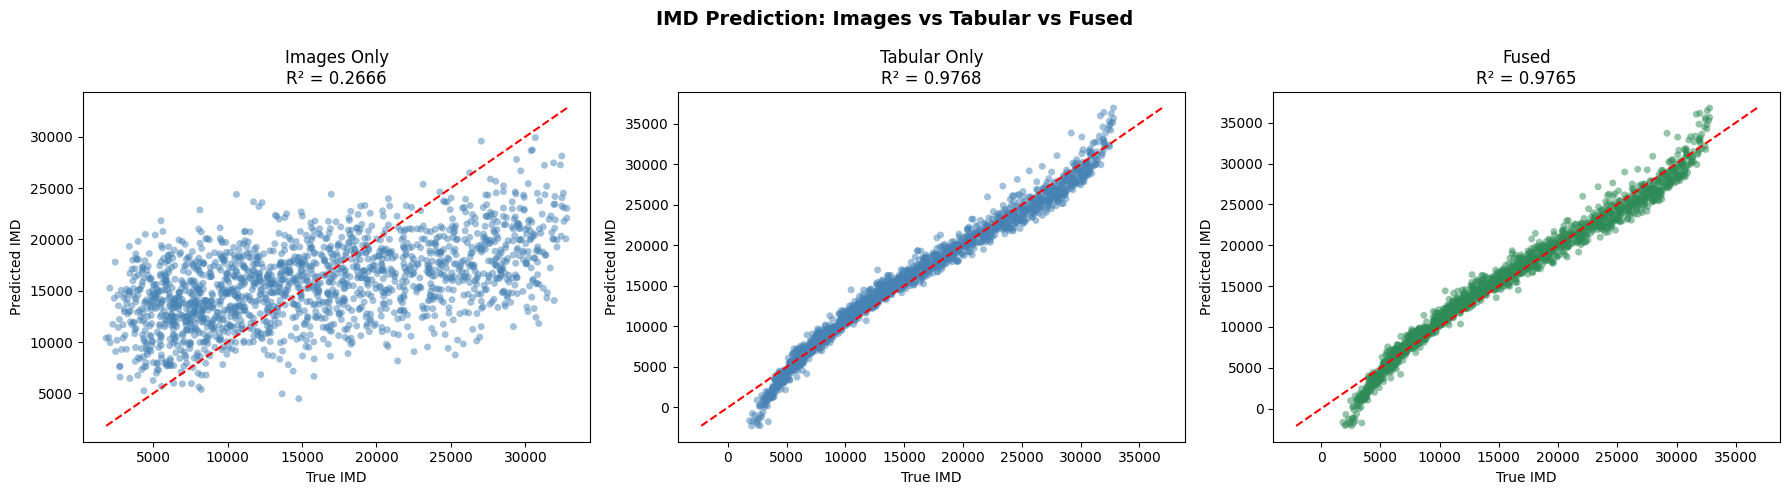

Best OOF R²: 0.9765


In [ ]:
# ── Plots ─────────────────────────────────────────────────────────────────────
os.makedirs('outputs', exist_ok=True)

best_oof = oof_preds_fused
best_r2  = r2_score(y, best_oof)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, title, r2 in zip(
    axes,
    [oof_preds_img_only, oof_preds_tab_only, oof_preds_fused],
    ['Images Only', 'Tabular Only', 'Fused'],
    [r2_score(y, oof_preds_img_only), r2_score(y, oof_preds_tab_only), r2_score(y, oof_preds_fused)]
):
    ax.scatter(y, preds, alpha=0.5, s=25, edgecolors='none',
               color='steelblue' if title != 'Fused' else 'seagreen')
    lims = [min(y.min(), preds.min()), max(y.max(), preds.max())]
    ax.plot(lims, lims, 'r--', lw=1.5)
    ax.set_title(f'{title}\nR² = {r2:.4f}', fontsize=12)
    ax.set_xlabel('True IMD')
    ax.set_ylabel('Predicted IMD')

plt.suptitle('IMD Prediction: Images vs Tabular vs Fused', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best OOF R²: {best_r2:.4f}')

In [ ]:
# ── Save final model ──────────────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)

img_scaler_f = StandardScaler()
Xi_all_s = img_scaler_f.fit_transform(X_img)
pca_f = PCA(n_components=N_PCA, random_state=42)
Xi_all_pca = pca_f.fit_transform(Xi_all_s)

tab_scaler_f = StandardScaler()
Xt_all_s = tab_scaler_f.fit_transform(X_tab)

X_fused_all = np.hstack([Xi_all_pca, Xt_all_s])
y_mean_f, y_std_f = y.mean(), y.std()
y_norm_f = (y - y_mean_f) / y_std_f

ridge_f = RidgeCV(alphas=np.logspace(-2, 4, 50), cv=5)
ridge_f.fit(X_fused_all, y_norm_f)

with open('models/final_fused_bundle.pkl', 'wb') as f:
    pickle.dump({
        'img_scaler': img_scaler_f, 'pca': pca_f,
        'tab_scaler': tab_scaler_f, 'ridge': ridge_f,
        'y_mean': y_mean_f, 'y_std': y_std_f,
        'score_cols': score_feature_cols
    }, f)

print('Saved to models/final_fused_bundle.pkl')
print(f'Final Ridge alpha: {ridge_f.alpha_:.4f}')

Saved to models/final_fused_bundle.pkl
Final Ridge alpha: 0.0100
